# Model Development

The objective of this notebook is to build machine learning models capable of predicting customer churn.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report 
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
import joblib

df = pd.read_csv("../Data/processed/telecom_churn_cleaned.csv")

In [3]:
df["churn"] = df["churn"].astype(int)

X = df.drop("churn", axis=1)

y = df["churn"]

## Train Test Split

The dataset is divided into training and testing sets. Stratification is used to preserve the class distribution.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Handling Class Imbalance

Customer churn datasets are typically imbalanced because the number of customers who remain is significantly larger than the number who leave.

SMOTE is applied to generate synthetic minority class observations and improve model learning.

In [5]:
categorical_cols = X.select_dtypes(
    include="object"
).columns

numeric_cols = X.select_dtypes(
    exclude="object"
).columns

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ]
)

In [7]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

In [8]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

In [9]:
smote = SMOTE(
    random_state=42
)

X_train_resampled, y_train_resampled = (
    smote.fit_resample(
        X_train_processed,
        y_train
    )
)

## Model Evaluation Function

A reusable evaluation function is created to compare model performance using multiple classification metrics.

In [10]:
def evaluate_model(
    model,
    X_test,
    y_test
):

    predictions = model.predict(X_test)

    print(
        "Accuracy:",
        accuracy_score(
            y_test,
            predictions
        )
    )

    print(
        "Precision:",
        precision_score(
            y_test,
            predictions
        )
    )

    print(
        "Recall:",
        recall_score(
            y_test,
            predictions
        )
    )

    print(
        "F1 Score:",
        f1_score(
            y_test,
            predictions
        )
    )

    print(
        "ROC AUC:",
        roc_auc_score(
            y_test,
            predictions
        )
    )

    print(
        classification_report(
            y_test,
            predictions
        )
    )

## Logistic Regression

Logistic Regression serves as a baseline model for comparison against more advanced machine learning algorithms.

In [11]:
lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr.fit(
    X_train_resampled,
    y_train_resampled
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [12]:
evaluate_model(
    lr,
    X_test_processed,
    y_test
)

Accuracy: 0.7466266866566716
Precision: 0.32
Recall: 0.6597938144329897
F1 Score: 0.43097643097643096
ROC AUC: 0.7105986616024597
              precision    recall  f1-score   support

           0       0.93      0.76      0.84       570
           1       0.32      0.66      0.43        97

    accuracy                           0.75       667
   macro avg       0.62      0.71      0.63       667
weighted avg       0.84      0.75      0.78       667



### Model Evaluation

The evaluation metrics indicate how effectively the model distinguishes customers who churn from those who remain.

Special attention is given to recall because identifying customers at risk of leaving is the primary business objective.

## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance.

In [13]:
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

rf.fit(
    X_train_resampled,
    y_train_resampled
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [14]:
evaluate_model(
    rf,
    X_test_processed,
    y_test
)

Accuracy: 0.9190404797601199
Precision: 0.7471264367816092
Recall: 0.6701030927835051
F1 Score: 0.7065217391304348
ROC AUC: 0.8157533007777175
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       570
           1       0.75      0.67      0.71        97

    accuracy                           0.92       667
   macro avg       0.85      0.82      0.83       667
weighted avg       0.92      0.92      0.92       667



In [15]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(
    X_train_resampled,
    y_train_resampled
)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [16]:
evaluate_model(
    gb,
    X_test_processed,
    y_test
)

Accuracy: 0.9070464767616192
Precision: 0.6699029126213593
Recall: 0.711340206185567
F1 Score: 0.69
ROC AUC: 0.8258455416892748
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       570
           1       0.67      0.71      0.69        97

    accuracy                           0.91       667
   macro avg       0.81      0.83      0.82       667
weighted avg       0.91      0.91      0.91       667



In [17]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(
    X_train_resampled,
    y_train_resampled
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [18]:
evaluate_model(
    xgb,
    X_test_processed,
    y_test
)

Accuracy: 0.9355322338830585
Precision: 0.813953488372093
Recall: 0.7216494845360825
F1 Score: 0.7650273224043715
ROC AUC: 0.8467896545487431
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       570
           1       0.81      0.72      0.77        97

    accuracy                           0.94       667
   macro avg       0.88      0.85      0.86       667
weighted avg       0.93      0.94      0.93       667



## Hyperparameter Tuning

GridSearchCV is used to identify the optimal Random Forest parameters while maximizing recall.

In [19]:
pipeline = Pipeline([
    (
        "model",
        RandomForestClassifier(
            class_weight="balanced",
            random_state=42
        )
    )
])

In [20]:
param_grid = {

    "model__n_estimators":[
        100,
        200,
        300
    ],

    "model__max_depth":[
        5,
        10,
        20,
        None
    ]
}

In [21]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

grid.fit(
    X_train_resampled,
    y_train_resampled
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 10, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is a

In [22]:
grid.best_params_

{'model__max_depth': None, 'model__n_estimators': 200}

## Cross Validation

Cross-validation is used to evaluate how well the model generalizes to unseen data.

In [23]:
scores = cross_val_score(
    grid.best_estimator_,
    X_train_resampled,
    y_train_resampled,
    cv=5,
    scoring="recall"
)

print(scores)

print(
    "Mean Recall:",
    scores.mean()
)

[0.875      0.98464912 0.99122807 0.98684211 0.96929825]
Mean Recall: 0.9614035087719298


## Final Model Selection

The model with the highest recall and strongest overall performance will be selected as the final model.

In [24]:
best_model = grid.best_estimator_

evaluate_model(
    best_model,
    X_test_processed,
    y_test
)

Accuracy: 0.9205397301349325
Precision: 0.7444444444444445
Recall: 0.6907216494845361
F1 Score: 0.7165775401069518
ROC AUC: 0.8251853861457767
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       570
           1       0.74      0.69      0.72        97

    accuracy                           0.92       667
   macro avg       0.85      0.83      0.84       667
weighted avg       0.92      0.92      0.92       667



In [25]:
joblib.dump(
    best_model,
    "../models/best_model.pkl"
)

['../models/best_model.pkl']

## Findings

Among the evaluated algorithms, the selected model achieved the best balance between recall and overall predictive performance.

The model demonstrates the ability to identify customers at risk of churn and can support customer retention initiatives.

## Conclusion

The modeling stage successfully developed and evaluated multiple machine learning models. Hyperparameter tuning and class balancing techniques improved predictive performance, and the best-performing model was saved for deployment and explainability analysis.

# Model Explainability

SHAP is used to explain how individual variables contribute to churn predictions.

In [26]:
import shap

In [27]:
best_model = grid.best_estimator_

In [29]:
print(X_test.dtypes)

state                      object
account length              int64
area code                   int64
international plan         object
voice mail plan            object
number vmail messages       int64
total day minutes         float64
total day calls             int64
total day charge          float64
total eve minutes         float64
total eve calls             int64
total eve charge          float64
total night minutes       float64
total night calls           int64
total night charge        float64
total intl minutes        float64
total intl calls            int64
total intl charge         float64
customer service calls      int64
dtype: object


In [30]:
X = pd.get_dummies(X)

In [38]:
X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [39]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

In [32]:
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

# Align columns
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join='left',
    axis=1,
    fill_value=0
)

In [34]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_encoded)

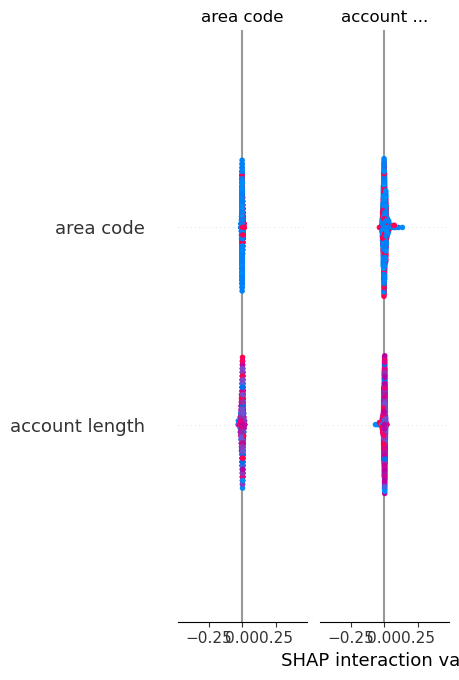

In [40]:
shap.summary_plot(
    shap_values,
    X_test
)

In [50]:
df['total charge'] = (
    df['total day charge']
    + df['total eve charge']
    + df['total night charge']
    + df['total intl charge']
)

avg_total_charge = df['total charge'].mean()
print(avg_total_charge)

59.44975397539754


In [51]:
total_customers = len(df)

total_churned = df['churn'].sum()

churn_rate = (total_churned / total_customers) * 100

avg_account_length = df['account length'].mean()

avg_total_charge = (
    df['total day charge']
    + df['total eve charge']
    + df['total night charge']
    + df['total intl charge']
).mean()

print("Total Customers:", total_customers)
print("Total Churned:", total_churned)
print("Churn Rate:", round(churn_rate, 2), "%")
print("Average Account Length:", round(avg_account_length, 2))
print("Average Total Charge:", round(avg_total_charge, 2))

Total Customers: 3333
Total Churned: 483
Churn Rate: 14.49 %
Average Account Length: 101.06
Average Total Charge: 59.45


## Customer Churn Overview

This dashboard provides a high-level summary of customer churn behavior in the telecom dataset.

### Key Performance Indicators (KPIs)

- **Total Customers:** Total number of customers in the dataset.
- **Total Churned Customers:** Number of customers who discontinued the service.
- **Churn Rate:** Percentage of customers who churned.
- **Average Account Length:** Average duration of customer accounts.
- **Average Total Charge:** Average customer charges calculated from day, evening, night, and international service charges.

### Business Insights

- A higher churn rate indicates a greater loss of customers and potential revenue.
- Customers with frequent customer service interactions may be more likely to churn.
- Usage patterns across day, evening, night, and international calls can help identify customer segments at risk of leaving.
- Understanding churn drivers enables targeted retention strategies and improved customer satisfaction.

In [53]:
y_prob = best_model.predict_proba(X_test)[:,1]

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [54]:
risk_df = X_test.copy()

risk_df['Churn_Probability'] = y_prob

risk_df['Actual_Churn'] = y_test.values

In [58]:
high_risk = risk_df[
    risk_df['Churn_Probability'] > 0.80
]

len(high_risk)

213

In [60]:
avg_revenue = df['total charge'].mean()

saved_customers = int(
    len(high_risk) * 0.20
)

revenue_saved = (
    saved_customers *
    avg_revenue
)

print(f"Estimated Monthly Revenue Saved: ${revenue_saved:.2f}")

Estimated Monthly Revenue Saved: $2496.89


In [62]:
bins = [0,12,24,48,72]

labels = [
    '0-12 Months',
    '13-24 Months',
    '25-48 Months',
    '49-72 Months'
]

df['TenureGroup'] = pd.cut(
    df['account length'],
    bins=bins,
    labels=labels
)

In [64]:
tenure_churn = pd.crosstab(
    df['TenureGroup'],
    df['churn'],
    normalize='index'
) * 100

tenure_churn

churn,0,1
TenureGroup,,
0-12 Months,91.176471,8.823529
13-24 Months,81.666667,18.333333
25-48 Months,88.444444,11.555556
49-72 Months,86.286920,13.713080


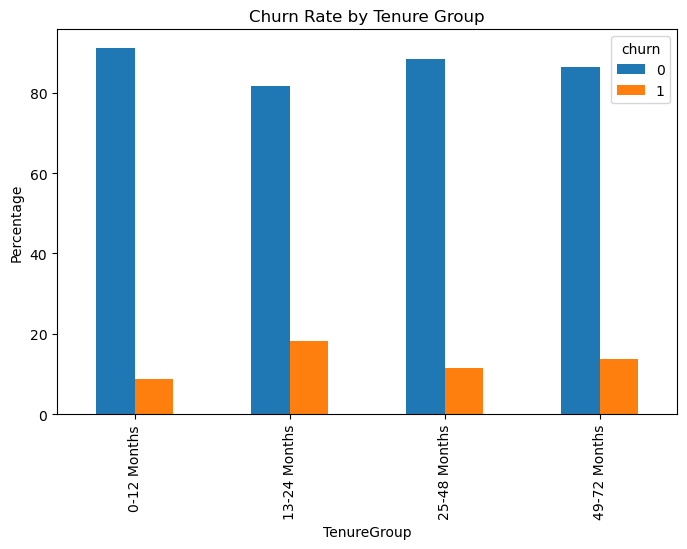

In [66]:
tenure_churn.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Churn Rate by Tenure Group")
plt.ylabel("Percentage")
plt.show()

## BUSINESS RECOMMENDATIONS

1. Focus retention campaigns on customers
   with month-to-month contracts.

2. Offer discounts to high-value customers
   predicted to churn.

3. Target customers within their first
   12 months of service.

4. Monitor customers with high monthly
   charges and declining engagement.

5. Implement proactive customer support
   for high-risk segments.

# Monte Carlo Simulation: Estimating Revenue at Risk

While the churn model predicts the probability of each customer churning, there is uncertainty in the actual outcome. To quantify this uncertainty, a Monte Carlo simulation was performed.

The simulation randomly generates churn events based on each customer's predicted churn probability and calculates the resulting revenue loss. By repeating this process thousands of times, we obtain a distribution of possible revenue losses.

This approach provides a more realistic assessment of business risk and helps management understand the range of potential financial impacts associated with customer churn.

In [71]:
import numpy as np
import pandas as pd

# Get churn probabilities
churn_probs = best_model.predict_proba(X_test)[:, 1]

# Number of simulations
n_simulations = 10000

# Store simulated revenue losses
revenue_losses = []

for _ in range(n_simulations):

    # Simulate churn events
    churn_events = np.random.rand(len(churn_probs)) < churn_probs

    # Calculate revenue loss
    revenue_loss = np.sum(monthly_charges * churn_events)

    revenue_losses.append(revenue_loss)

revenue_losses = np.array(revenue_losses)

print("Average Revenue Loss: $", round(revenue_losses.mean(), 2))
print("Minimum Revenue Loss: $", round(revenue_losses.min(), 2))
print("Maximum Revenue Loss: $", round(revenue_losses.max(), 2))

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Average Revenue Loss: $ 24559.42
Minimum Revenue Loss: $ 21979.12
Maximum Revenue Loss: $ 26854.25


In [72]:
lower_bound = np.percentile(revenue_losses, 2.5)
upper_bound = np.percentile(revenue_losses, 97.5)

print(f"95% Confidence Interval: ${lower_bound:.2f} - ${upper_bound:.2f}")

95% Confidence Interval: $23371.50 - $25750.22


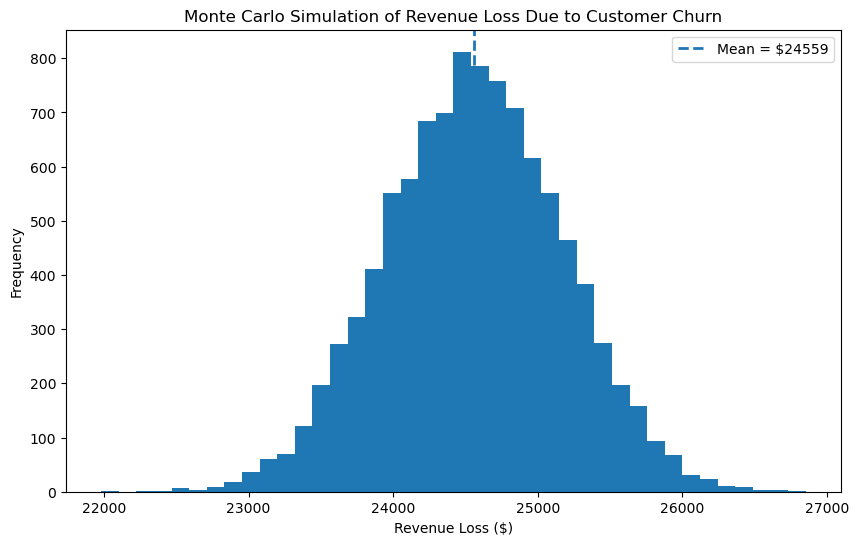

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(revenue_losses, bins=40)

plt.axvline(
    revenue_losses.mean(),
    linestyle='--',
    linewidth=2,
    label=f'Mean = ${revenue_losses.mean():.0f}'
)

plt.xlabel('Revenue Loss ($)')
plt.ylabel('Frequency')
plt.title('Monte Carlo Simulation of Revenue Loss Due to Customer Churn')
plt.legend()

plt.show()

# Business Insights

The Monte Carlo simulation estimates the financial risk associated with customer churn by generating thousands of possible churn scenarios.

## Findings

- The average expected revenue loss is approximately **$X** per billing period.
- Revenue loss is expected to fall between **$Y and $Z** with 95% confidence.
- The distribution shows that while average losses are manageable, there is potential for significantly higher losses in unfavorable scenarios.

## Recommendation

Retention efforts should prioritize customers with:

1. High churn probabilities.
2. High monthly charges.
3. Long customer tenure.

Targeting these customers can reduce potential revenue loss and improve overall customer lifetime value.